In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import palette_genders, palette_treatment, mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.tf_activity.helper import retrieve_feature_data, retrieve_adata_bulk, retrieve_net, calculate_tf_activity, retrieve_sig_stats
from ciim.src.tf_activity.plots import  plot_net_nx, plot_trend_tfs

from ciim.src.utils.plots import dotplot

# Train

In [12]:
!python ../src/clock/script.py

building model for cell type: CD4T
data1  feature space:  (981, 87)
data7_allTPs_jalil  feature space:  (313, 87)
data12  feature space:  (61, 87)
data13_Korean  feature space:  (165, 87)
data13_Japanese  feature space:  (148, 87)
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
building model for cell type: CD8T
data1  feature space:  (981, 142)
data7_allTPs_jalil  feature space:  (313, 142)
data12  feature space:  (61, 142)
data13_Korean  feature space:  (165, 142)
data13_Japanese  feature space:  (147, 142)
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
building model for cell type: NK
data1  feature space:  (981, 44)
dat

# Evaluation

In [13]:
from ciim.src.clock.helper import predict_age, prepare_input

datasets = ['data1', 'data7_allTPs_jalil', 'data12', 'SLE_European', 'data13_Korean' , 'data13_Japanese', 'CXCL9'] # 'data1' CXCL9 SLE_European SLE_Asian

obs_store = []
for cell_type in cell_types:
    # - load the data
    for dataset in datasets:
        adata = prepare_input(dataset, cell_type)

        adata.obs.rename(columns={'disease': 'condition', 'treatment':'condition'}, inplace=True)

        if 'condition' not in adata.obs.columns:
            adata.obs['condition'] = 'healthy'
        conds = adata.obs['condition'].unique()
        for cond in conds:
            adata_c = adata[adata.obs['condition'] == cond]
            adata_c = predict_age(adata_c, cell_type)
            obs = adata_c.obs[['age', 'predicted_age', 'sex', 'donor_id']].copy() 
            obs['dataset'] = dataset
            obs['cell_type'] = cell_type
            obs['condition'] = cond
            obs_store.append(obs)
obs = pd.concat(obs_store, axis=0)
obs.head()

data1  feature space:  (981, 87)
data7_allTPs_jalil  feature space:  (313, 87)
data12  feature space:  (61, 87)
SLE_European  feature space:  (150, 87)
data13_Korean  feature space:  (165, 87)
data13_Japanese  feature space:  (148, 87)
CXCL9  feature space:  (77, 87)
data1  feature space:  (981, 142)
data7_allTPs_jalil  feature space:  (313, 142)
data12  feature space:  (61, 142)
SLE_European  feature space:  (150, 142)
data13_Korean  feature space:  (165, 142)
data13_Japanese  feature space:  (147, 142)
CXCL9  feature space:  (77, 142)
data1  feature space:  (981, 44)
data7_allTPs_jalil  feature space:  (313, 44)
data12  feature space:  (61, 44)
SLE_European  feature space:  (150, 44)
data13_Korean  feature space:  (164, 44)
data13_Japanese  feature space:  (147, 44)
CXCL9  feature space:  (77, 44)
data1  feature space:  (978, 78)
data7_allTPs_jalil  feature space:  (312, 78)
data12  feature space:  (60, 78)
SLE_European  feature space:  (148, 78)
data13_Korean  feature space:  (165, 

,age,predicted_age,sex,donor_id,dataset,cell_type,condition
sample,,,,,,,
1000,80,79.688691,Female,Data1_1020_1021,data1,CD4T,healthy
1001,75,76.410921,Female,Data1_1021_1022,data1,CD4T,healthy
1002,68,58.544947,Female,Data1_1022_1023,data1,CD4T,healthy
1003,60,60.746485,Female,Data1_1023_1024,data1,CD4T,healthy
1004,70,76.029458,Female,Data1_1024_1025,data1,CD4T,healthy


## Performance on train data

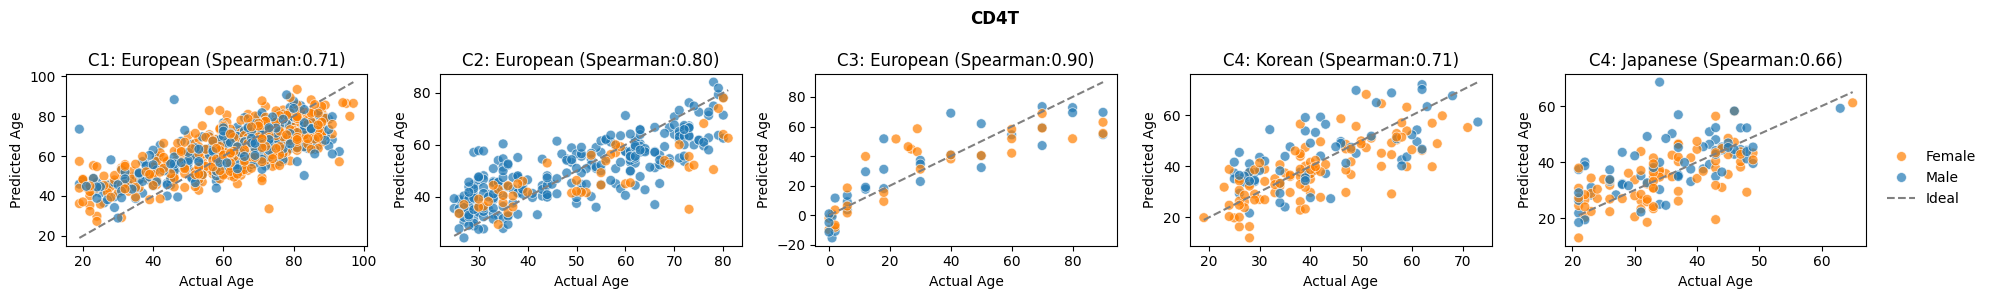

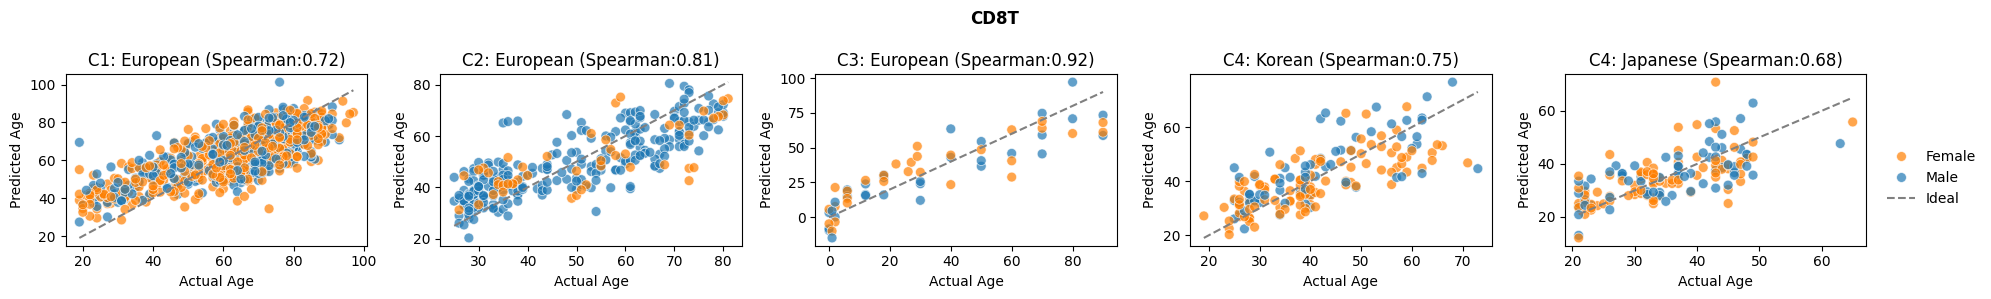

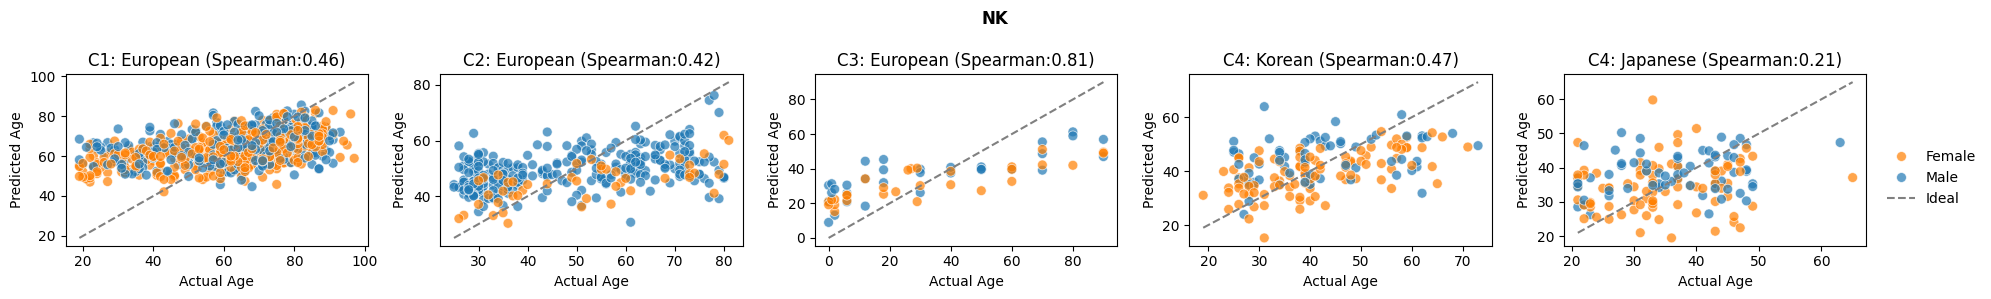

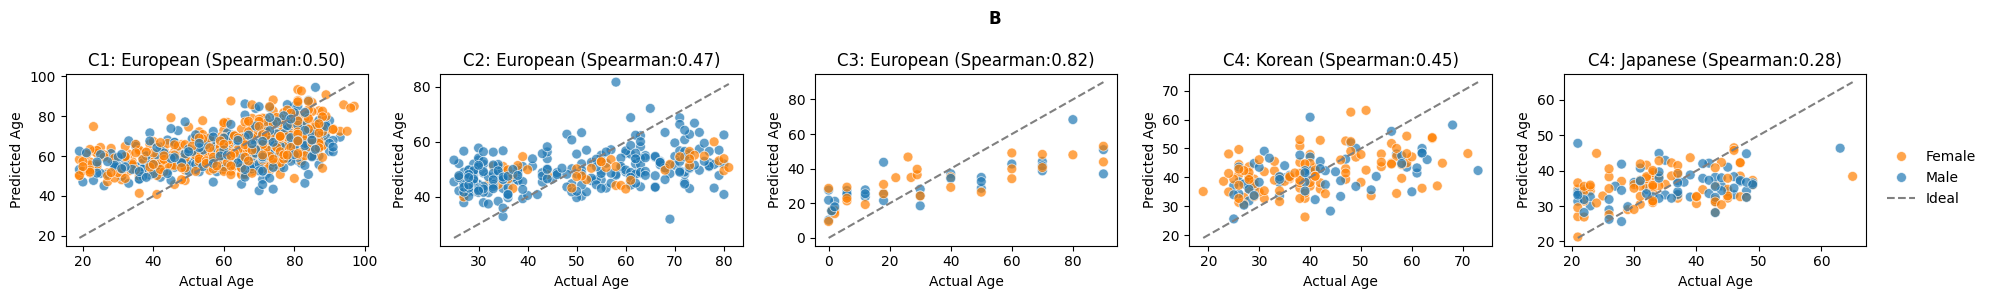

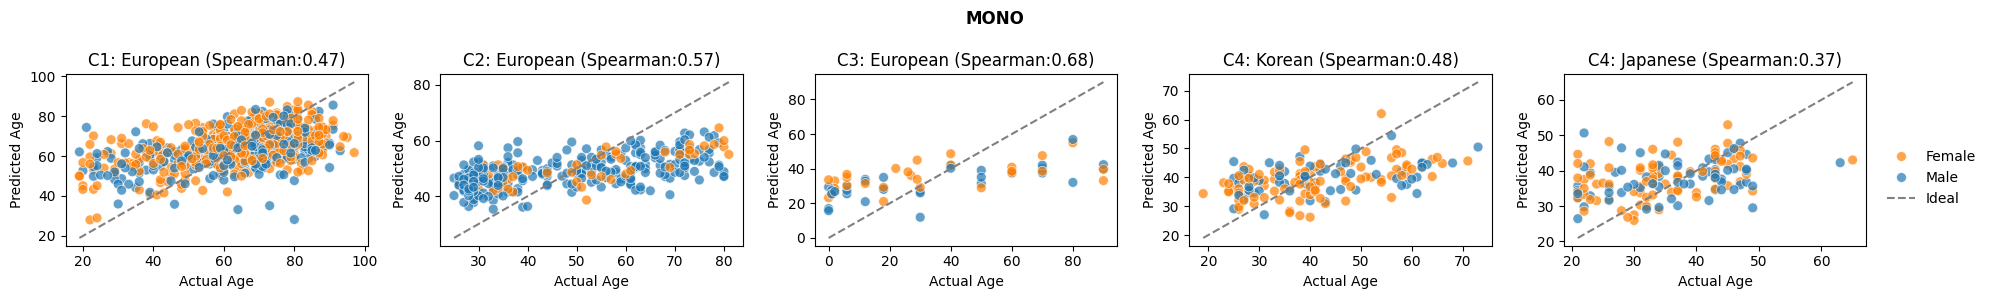

In [14]:
datasets_healthy = obs[obs['condition'] == 'healthy']['dataset'].unique()
for cell_type in cell_types:
    fig, axes = plt.subplots(1, len(datasets_healthy), figsize=(4*len(datasets_healthy), 3))
    i = 0
    for dataset in datasets_healthy:
        ax = axes[i] if len(datasets_healthy) > 1 else axes
        obs_d = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()
        sns.scatterplot(data=obs_d, x='age', y='predicted_age', s=50, alpha=0.7, hue='sex', ax=ax, palette=palette_genders)
        min_age, max_age = obs_d['age'].min(), obs_d['age'].max()
        ax.plot([min_age, max_age], [min_age, max_age], color='gray', linestyle='--', label='Ideal')

        ax.set_xlabel("Actual Age")
        ax.set_ylabel("Predicted Age")

        spearman = spearmanr(obs_d['age'], obs_d['predicted_age'])[0]
        ax.set_title(f"{surrogate_names[dataset]} (Spearman:{spearman:.2f})")
        ax.get_legend().remove()
        
        i+=1
    
    ax.legend(loc=(1.05, .2), frameon=False)
    plt.suptitle(cell_type, fontsize=12, weight='bold')
    plt.tight_layout()

## Performance on SLE

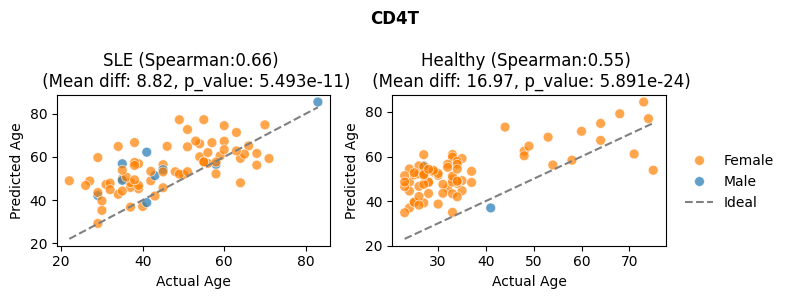

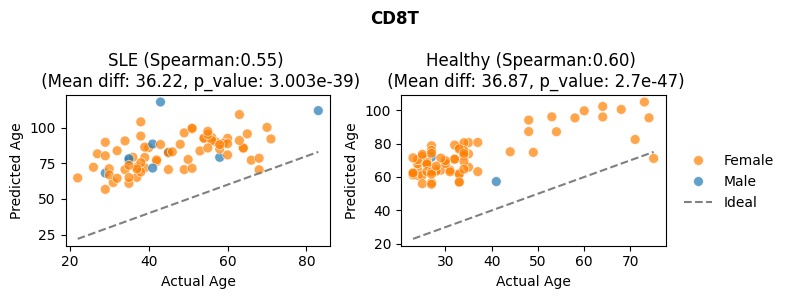

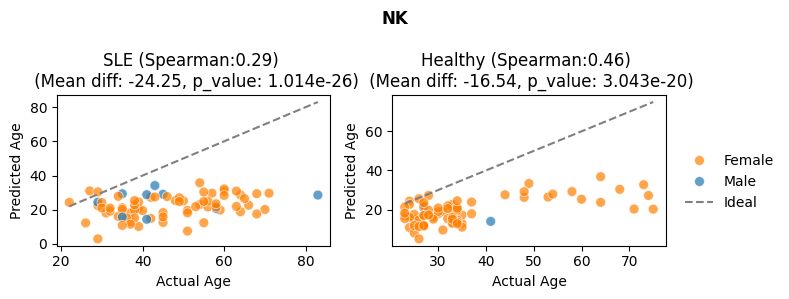

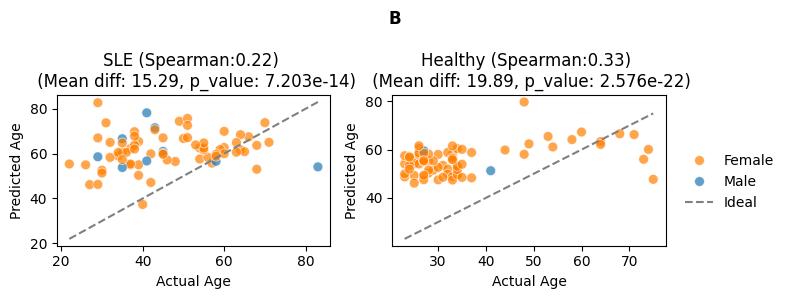

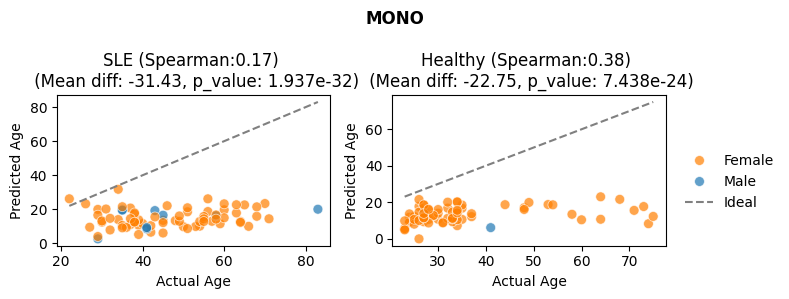

In [15]:
import scipy.stats as stats

obs_sle = obs[obs['dataset'] == 'SLE_European'].copy()
conds = obs_sle['condition'].unique()

for cell_type in cell_types:
    fig, axes = plt.subplots(1, len(conds), figsize=(4*len(conds), 3))
    for i, cond in enumerate(conds):
        ax = axes[i] if len(conds) > 1 else axes
        obs_d = obs_sle[(obs_sle['cell_type'] == cell_type) & (obs_sle['condition'] == cond)].copy()

        # - plot the goodness
        age_diff = obs_d['predicted_age'] - obs_d['age']
        
        # One-sample t-test
        t_stat, p_value = stats.ttest_1samp(age_diff, 0)
        mean_diff = age_diff.mean()
        
        # plt.title(f"{cond}\np = {p_value:.4g}, Mean age diff = {mean_diff:.2f}")
        

        sns.scatterplot(data=obs_d, x='age', y='predicted_age', s=50, alpha=0.7, hue='sex', ax=ax, palette=palette_genders)
        min_age, max_age = obs_d['age'].min(), obs_d['age'].max()
        ax.plot([min_age, max_age], [min_age, max_age], color='gray', linestyle='--', label='Ideal')

        ax.set_xlabel("Actual Age")
        ax.set_ylabel("Predicted Age")

        spearman = spearmanr(obs_d['age'], obs_d['predicted_age'])[0]
        ax.set_title(f"{surrogate_names[cond]} (Spearman:{spearman:.2f}) \n (Mean diff: {mean_diff:.2f}, p_value: {p_value:.4g})")
        ax.get_legend().remove()
        
        i+=1
    
    ax.legend(loc=(1.05, .2), frameon=False)
    plt.suptitle(cell_type, fontsize=12, weight='bold')
    plt.tight_layout()


## Drug perturbation

In [16]:
obs_cxcl9 = obs[obs['dataset'] == 'CXCL9'].copy() 
obs_cxcl9['condition'].unique()

array(['24 h LPS', '24 h LPS + metformin',
       '24 h LPS + metformin + ruxolitinib', '24 h LPS + ruxolitinib',
       '24 h RPMI', '24 h RPMI + metformin',
       '24 h RPMI + metformin + ruxolitinib', '24 h RPMI + ruxolitinib',
       '24 h rhCXCL9', '24 h rhIFN-γ', '0 h Unstimulated'], dtype=object)

In [27]:
pretty_names = {
    '24 h LPS': 'LPS',
    '24 h LPS + metformin': 'LPS+Metformin',
    '24 h LPS + metformin + ruxolitinib': 'LPS+Met.+Rux.', #Ruxolitinib
    '24 h LPS + ruxolitinib': 'LPS+Rux.',
    '24 h RPMI': 'RPMI',
    '24 h RPMI + metformin': 'RPMI+Metformin',
    '24 h RPMI + metformin + ruxolitinib': 'RPMI+Met.+Rux.',
    '24 h RPMI + ruxolitinib': 'RPMI+Rux.',
    '24 h RPMI': 'RPMI',
    '24 h rhCXCL9': 'rhCXCL9',
    '24 h rhIFN-γ': 'rhIFN-γ'
}

experiments = [
                # ('24 h RPMI', '24 h rhCXCL9'),
                ('24 h RPMI', '24 h LPS'),
                # ('24 h RPMI', '24 h rhIFN-γ'),
                ('24 h RPMI', '24 h RPMI + metformin'),
                ('24 h RPMI', '24 h RPMI + ruxolitinib'),
                ('24 h RPMI', '24 h RPMI + metformin + ruxolitinib'),
                ('24 h LPS', '24 h LPS + metformin'),
                ('24 h LPS', '24 h LPS + ruxolitinib'),
                ('24 h LPS', '24 h LPS + metformin + ruxolitinib'),
                ]
n_exp = len(experiments)

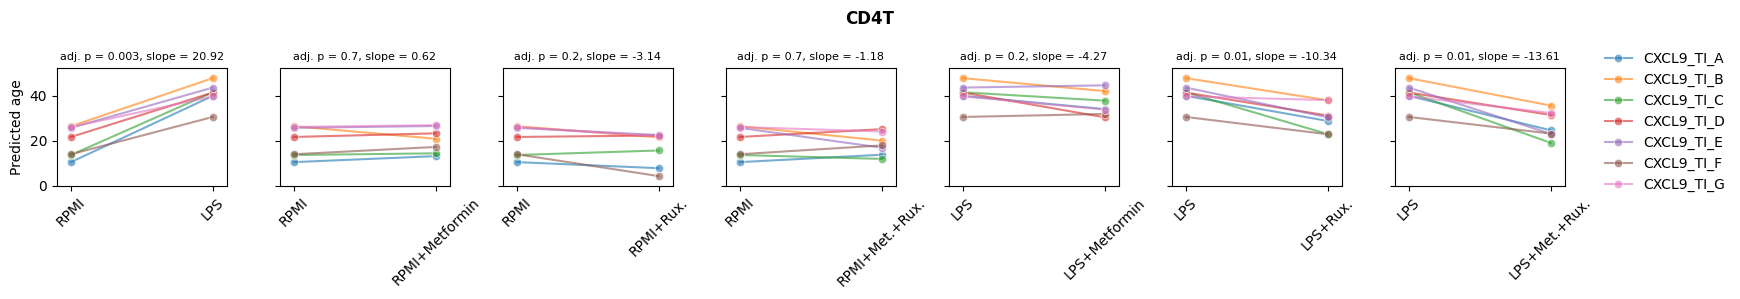

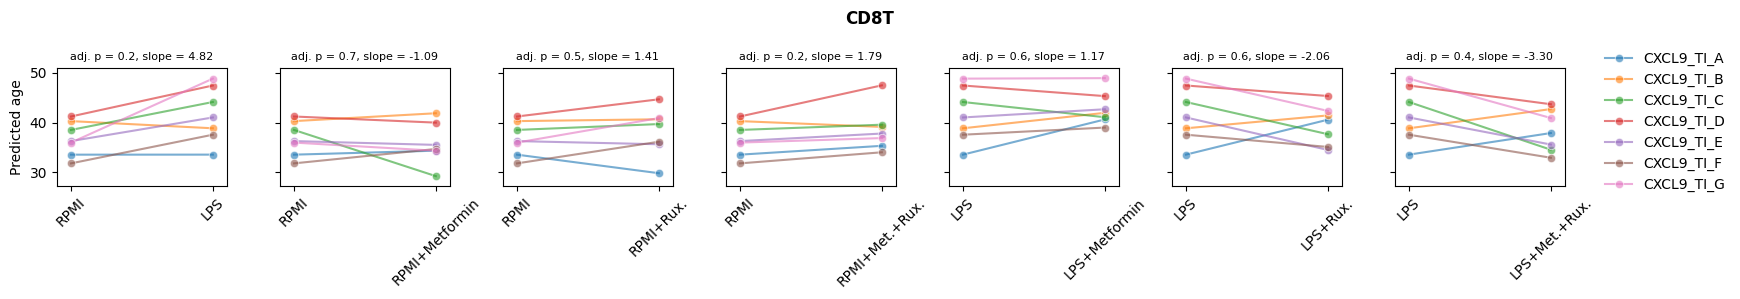

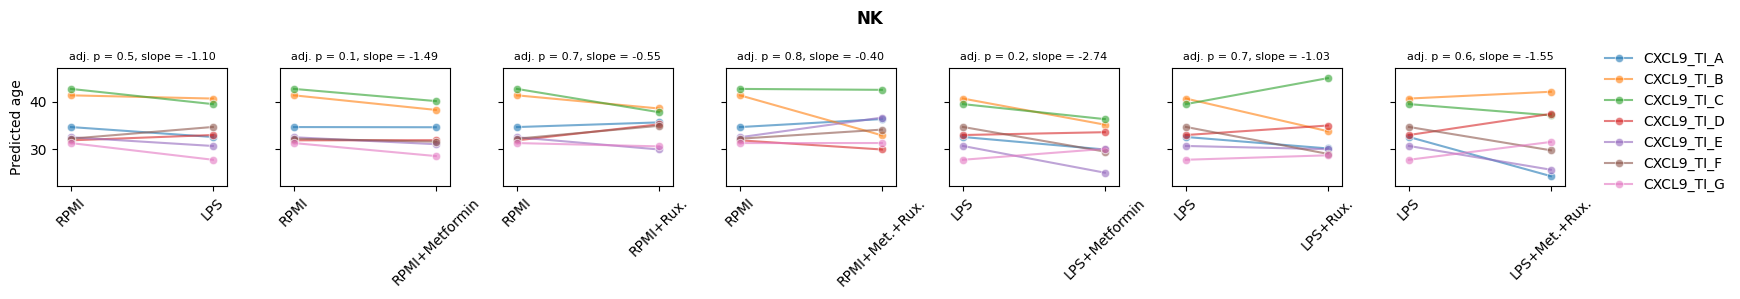

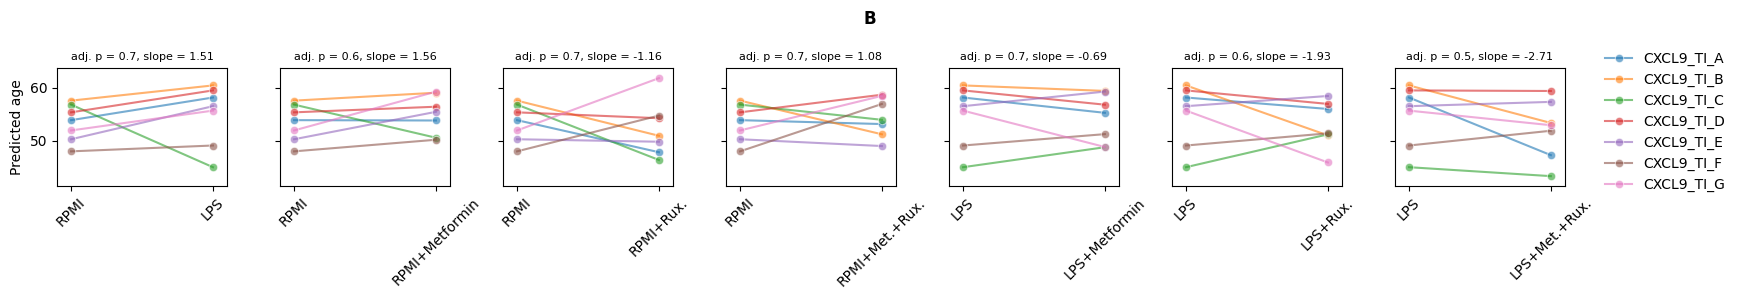

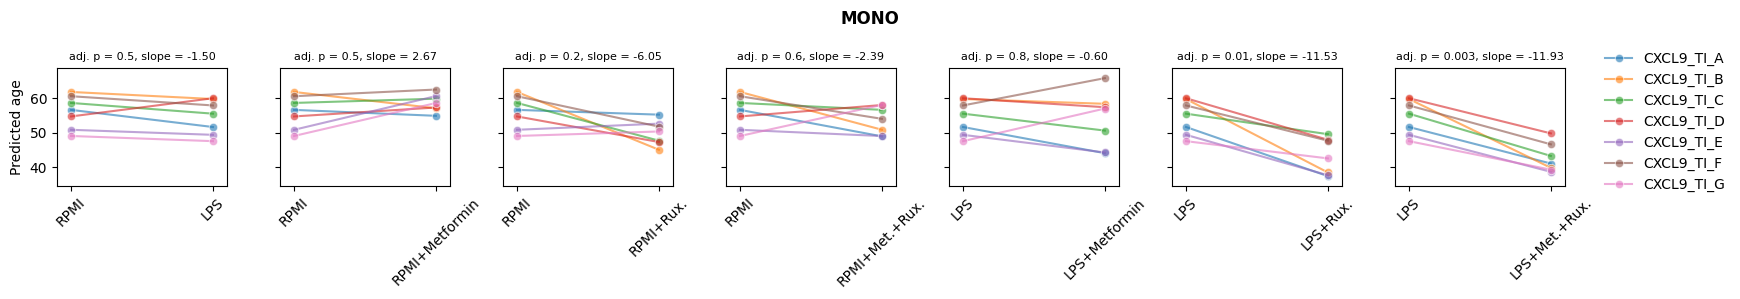

In [28]:
from statsmodels.stats.multitest import multipletests

# Store raw p-values and labels for later correction
raw_pvals = []
test_labels = []  # e.g., f"{cell_type}_{ctr}_vs_{treatment}"
slopes = []

for cell_type in obs_cxcl9['cell_type'].unique():
    obs_t = obs_cxcl9[obs_cxcl9['cell_type'] == cell_type].copy()
    df_all = obs_t[['donor_id', 'condition', 'predicted_age']].copy()

    for i, (ctr, treatment) in enumerate(experiments):
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        df_pivot = df_sub.pivot(index='donor_id', columns='condition', values='predicted_age').dropna()

        if not df_pivot.empty:
            t_stat, p_value = stats.ttest_rel(df_pivot[treatment], df_pivot[ctr])
            raw_pvals.append(p_value)
            test_labels.append((cell_type, ctr, treatment))
            slope = (df_pivot[treatment] - df_pivot[ctr]).mean()
            slopes.append(slope)
        else:
            raw_pvals.append(1.0)  # fallback
            test_labels.append((cell_type, ctr, treatment))
            slopes.append(0)

# Apply FDR correction
rejected, corrected_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')

# Optionally: map corrected p-values back to plotting
pval_map = {
    (cell_type, ctr, treatment): (pval, slope)
    for (cell_type, ctr, treatment), pval, slope in zip(test_labels, corrected_pvals, slopes)
}

# Redraw plots with adjusted p-values
for cell_type in obs_cxcl9['cell_type'].unique():
    obs_t = obs_cxcl9[obs_cxcl9['cell_type'] == cell_type].copy()
    df_all = obs_t[['donor_id', 'condition', 'predicted_age']].copy()
    fig, axes = plt.subplots(1, n_exp, figsize=(2.5*n_exp, 3), sharey=True)

    for i, (ctr, treatment) in enumerate(experiments):
        ax = axes[i] if n_exp > 1 else axes
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        df_pivot = df_sub.pivot(index='donor_id', columns='condition', values='predicted_age').dropna()
        df_plot = df_pivot.reset_index().melt(id_vars='donor_id', 
                                              value_vars=[ctr, treatment],
                                              var_name='condition', 
                                              value_name='predicted_age')
        df_plot['condition'] = df_plot['condition'].map(pretty_names)
        sns.lineplot(data=df_plot, x='condition', y='predicted_age', 
                     hue='donor_id', marker='o', alpha=0.6, legend=True, ax=ax)
        
        pval, slope = pval_map.get((cell_type, ctr, treatment), (1.0, 0))
        ax.set_title(f"adj. p = {pval:.1g}, slope = {slope:.2f}", fontsize=8)
        ax.set_ylabel("Predicted age")
        ax.set_xlabel("")
        ax.margins(x=0.1, y=0.1)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        ax.get_legend().remove()
    ax.legend(loc=(1.2, -.1), frameon=False)
    plt.suptitle(cell_type, fontsize=12, weight='bold')
    plt.tight_layout()

# TF perturbation

In [19]:
cell_type = 'CD8T'

In [20]:
from ciim.src.tf_activity.helper import retrieve_sig_stats
from ciim.src.clock.helper import predict_age

# - sig stats
stats_sig = retrieve_sig_stats(type='bulk', race='both', filter_inconsistent=True)
stats_sig = stats_sig[stats_sig['cell_type'] == cell_type]
sig_tfs = stats_sig['tf'].unique()

In [21]:
dataset = 'data1'

In [22]:
def prepare_input_tf_perturbation(dataset, cell_type, age_range=[20, 80]) -> pd.Series:
    adata = retrieve_adata_bulk(dataset, type='bulk', cell_type=cell_type)
    # - bin 5 years and take the mean of the expression values
    expr_df = pd.DataFrame(adata.X.todense(), index=adata.obs.index, columns=adata.var_names)
    expr_df['age'] = adata.obs['age']
    expr_df = expr_df[(expr_df['age'] > age_range[0]) & (expr_df['age'] < age_range[1])].copy()  # Filter out age ranges
    expr_df['age_bin'] = (expr_df['age'].astype(int) // 5) * 5
    expr_df = expr_df.groupby('age_bin').mean().drop(columns='age')
    expr_df.index.name = 'age'

    # - define variables for the simulation
    max_delta = expr_df.max() - expr_df.min()
    return expr_df, max_delta
expr_df, max_delta = prepare_input_tf_perturbation(dataset, cell_type)

In [23]:
def perturb_tf(expr_df, tfs, max_delta):
    # - perturb the TFs
    expr_df_perturb = expr_df.copy()
    for tf in tfs:
        if tf in expr_df.columns:
            delta = max_delta[tf]
            expr_df_perturb[tf] += delta
    return expr_df_perturb
expr_df_perturb = perturb_tf(expr_df, sig_tfs[1:2], max_delta)

In [24]:
expr_adata = predict_age(expr_df, cell_type, feature_type='tf_activity')
expr_perturb_adata = predict_age(expr_df_perturb, cell_type, feature_type='tf_activity')

In [25]:
expr_adata.obs['condition'] = 'baseline'
expr_adata.obs['donor_id'] = expr_adata.obs.index
expr_perturb_adata.obs['condition'] = 'perturbation'
expr_perturb_adata.obs['donor_id'] = expr_adata.obs.index
adata_combined = ad.concat([expr_adata, expr_perturb_adata])

Paired t-test: t = 208145152476300.438, p = 3.954e-153
Mean difference (slope): 2.725


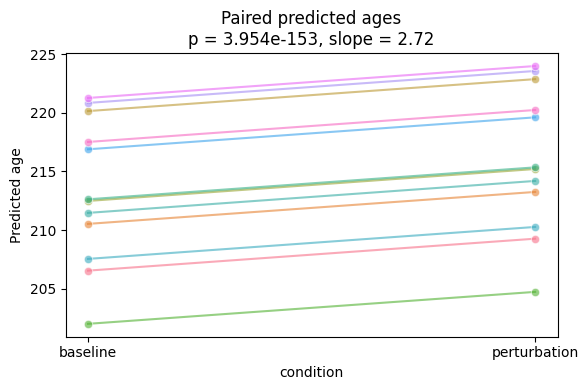

In [26]:
import pandas as pd
from scipy import stats

# Define conditions
ctr = 'baseline'
treatment = 'perturbation'

df_all = adata_combined.obs.copy()
# Filter to relevant conditions
df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()

# Pivot so each donor has one row with both conditions as columns
df_pivot = df_sub.pivot(index='donor_id', columns='condition', values='predicted_age')

# Drop donors with missing values in either condition
df_pivot = df_pivot.dropna(subset=[ctr, treatment])

# Perform paired t-test
t_stat, p_value = stats.ttest_rel(df_pivot[treatment], df_pivot[ctr])
slope = (df_pivot[treatment] - df_pivot[ctr]).mean()

print(f"Paired t-test: t = {t_stat:.3f}, p = {p_value:.4g}")
print(f"Mean difference (slope): {slope:.3f}")

# Reset index for plotting
df_plot = df_pivot.reset_index().melt(id_vars='donor_id', 
                                      value_vars=[ctr, treatment],
                                      var_name='condition', 
                                      value_name='predicted_age')

plt.figure(figsize=(6, 4))
sns.lineplot(data=df_plot, x='condition', y='predicted_age', 
             hue='donor_id', marker='o', alpha=0.6, legend=False)

plt.title(f"Paired predicted ages\np = {p_value:.4g}, slope = {slope:.2f}")
plt.ylabel("Predicted age")
plt.tight_layout()
plt.show()